In [1]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path


import logging


In [2]:
from utils import avg_pairwise_distance_by_label, get_cameo_codes
from train_embedding import cosine_distance, train_contrastive_loss, ContrastiveDataset, vectorize, clean_sample, make_sampler

In [3]:
logging.basicConfig(format='%(asctime)s|%(levelname)s|%(message)s',
                    # filename='output.log', 
                    encoding='utf-8', 
                    level=logging.INFO)
logger = logging.getLogger(__name__)

In [4]:
# global_db = pd.read_csv('/data/elugos/global_db_111125.csv')
input_file = "../data/train_20251214.csv"
df_train = pd.read_csv(Path(input_file))

/tmp/ipykernel_10288/3890808182.py:3: DtypeWarning: Columns (41,42) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv(Path(input_file))


In [5]:
# Cleanup and preprocess training data
# 

df_train_sample = clean_sample(df_train)

# Drop NaNs
df_train_sample = df_train_sample.dropna(subset=["embedding_json_title"])

# Make level column
df_train_sample['EventLabel'] = df_train_sample['EventRootCode']

# Drop duplicate titles
df_train_sample = df_train_sample.drop_duplicates(subset=['title'])

# Cleanup, remove unwanted columns
if 'level_0' in df_train_sample:
    df_train_sample.drop('level_0', axis=1, inplace=True)

print(f"Training samples: {len(df_train_sample)}")
df_train_sample.columns


Training samples: 44329


Index(['index', 'GlobalEventID', 'date', 'Year', 'Actor1Code', 'Actor1Name',
       'Actor1CountryCode', 'Actor1EthnicCode', 'Actor2Code', 'Actor2Name',
       'Actor2CountryCode', 'Actor2EthnicCode', 'IsRootEvent', 'EventCode',
       'EventBaseCode', 'EventRootCode', 'QuadClass', 'GoldsteinScale',
       'NumMentions', 'NumSources', 'NumArticles', 'AvgTone',
       'Actor1Geo_CountryCode', 'Actor2Geo_CountryCode', 'ActionGeo_Type',
       'ActionGeo_Fullname', 'ActionGeo_CountryCode', 'ActionGeo_ADM1Code',
       'ActionGeo_Lat', 'ActionGeo_Long', 'ActionGeo_FeatureID', 'DATEADDED',
       'SOURCEURL', 'domain', 'target', 'title', 'text', 'description',
       'sbert_text_title', 'embedding_json_title', 'sbert_text',
       'embedding_json', 'first_para', 'first_para_emb', 'EventLabel'],
      dtype='object')

In [6]:
cameo_codes = get_cameo_codes()

In [7]:
n_training = 100000
feature_col = "first_para_emb"  # 'first_para', 'embedding_json_title'
sampler = make_sampler(df_train_sample,n_training, 
                       col=feature_col, 
                       balanced_classes=True,
                       balanced_samples=True)

print(f"Input training data: {len(df_train_sample)} articles.")
print(f"Training pairs: {len(sampler)}")
print(f"  {sampler.value_counts('y')}")

Input training data: 44329 articles.
Training pairs: 200000
  y
0    100000
1    100000
Name: count, dtype: int64


In [8]:


i_np = vectorize(sampler["features-i"])
j_np = vectorize(sampler["features-j"])

i = torch.from_numpy(i_np)
j = torch.from_numpy(j_np)
# Random labels: 0 if dissimilar, 1 if similar.
#make the labels if similar 1, 0 if not
labels = torch.tensor(sampler["y"].values, dtype=torch.float32)

logger.info(f"{i.shape}, {j.shape}, {labels.shape}")


2025-12-15 19:36:50,913|INFO|torch.Size([200000, 384]), torch.Size([200000, 384]), torch.Size([200000])


In [9]:
input_dim = 384  # Just like SBERT embeddings
embed_dim = 300  # Chosen embedding dimension
margin = 1.0  # Choose a margin
batch_size=512  # the batch size
n_epochs = 50  # the number of epochs
lr = 0.01  # the learning rate

dataset = ContrastiveDataset(i, j, labels)
model, loss = train_contrastive_loss(dataset, embed_dim, margin=margin,
                                     dist_func=cosine_distance, 
                                     batch_size=batch_size,
                                     epochs=n_epochs,
                                     lr=lr
                                     )
logger.info(f"Model trained!")


2025-12-15 19:36:52,916|DEBUG|Epoch 1/50, Loss: 0.2528
2025-12-15 19:36:54,415|DEBUG|Epoch 2/50, Loss: 0.2413
2025-12-15 19:36:55,900|DEBUG|Epoch 3/50, Loss: 0.2378
2025-12-15 19:36:57,392|DEBUG|Epoch 4/50, Loss: 0.2359
2025-12-15 19:36:58,882|DEBUG|Epoch 5/50, Loss: 0.2344
2025-12-15 19:37:00,352|DEBUG|Epoch 6/50, Loss: 0.2335
2025-12-15 19:37:01,761|DEBUG|Epoch 7/50, Loss: 0.2328
2025-12-15 19:37:03,142|DEBUG|Epoch 8/50, Loss: 0.2321
2025-12-15 19:37:04,539|DEBUG|Epoch 9/50, Loss: 0.2316
2025-12-15 19:37:05,949|DEBUG|Epoch 10/50, Loss: 0.2311
2025-12-15 19:37:07,357|DEBUG|Epoch 11/50, Loss: 0.2308
2025-12-15 19:37:08,792|DEBUG|Epoch 12/50, Loss: 0.2304
2025-12-15 19:37:10,222|DEBUG|Epoch 13/50, Loss: 0.2302
2025-12-15 19:37:11,627|DEBUG|Epoch 14/50, Loss: 0.2298
2025-12-15 19:37:13,045|DEBUG|Epoch 15/50, Loss: 0.2296
2025-12-15 19:37:14,443|DEBUG|Epoch 16/50, Loss: 0.2293
2025-12-15 19:37:15,838|DEBUG|Epoch 17/50, Loss: 0.2291
2025-12-15 19:37:17,243|DEBUG|Epoch 18/50, Loss: 0.2289
2

2025-12-15 19:38:02,221|DEBUG|matplotlib data path: /home/mauricio/miniconda3/envs/cuda/lib/python3.13/site-packages/matplotlib/mpl-data
2025-12-15 19:38:02,223|DEBUG|CONFIGDIR=/home/mauricio/.config/matplotlib
2025-12-15 19:38:02,229|DEBUG|interactive is False
2025-12-15 19:38:02,229|DEBUG|platform is linux
2025-12-15 19:38:02,339|DEBUG|CACHEDIR=/home/mauricio/.cache/matplotlib
2025-12-15 19:38:02,340|DEBUG|Using fontManager instance from /home/mauricio/.cache/matplotlib/fontlist-v390.json
2025-12-15 19:38:02,411|DEBUG|Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-12-15 19:38:02,412|DEBUG|Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-12-15 19:38:02,413|DEBUG|findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2025-12-15 19:38:02,414|DEBUG|findfont: score(FontEntry(fname='/home/mauricio/miniconda3/envs/cuda/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/STIXNonUn

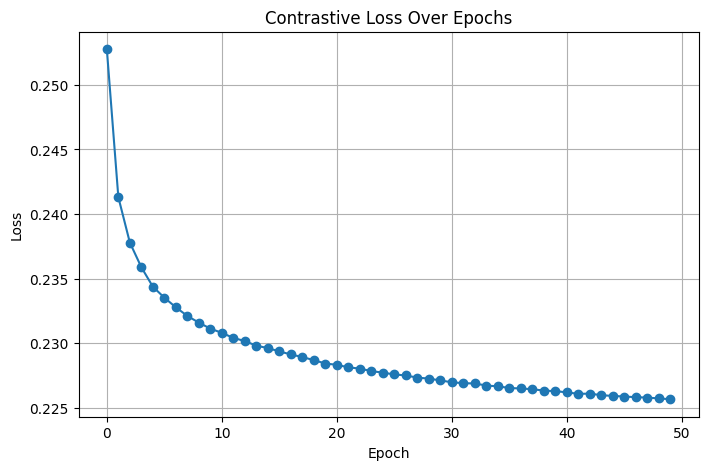

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(loss, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Contrastive Loss Over Epochs")
plt.grid(True)
plt.show()

In [11]:
model.eval()

with torch.no_grad():
    i_embed = model(i).cpu().numpy()   # shape: (N, embed_dim)
    j_embed = model(j).cpu().numpy()   # shape: (N, embed_dim)
    
all_embeddings = np.vstack([i_embed, j_embed])

global_ids = np.concatenate([sampler["GlobalEventID-i"].values,
                             sampler["GlobalEventID-j"].values])

all_labels = np.concatenate([labels.numpy(), labels.numpy()])
pair_flag   = np.array([0]*len(i_embed) + [1]*len(j_embed))  # blue = i, orange = j


In [12]:
sbert_same_dist, sbert_opp_dist, stats_sbert_35000 = avg_pairwise_distance_by_label(i, j, labels, metric="cosine")

# Learned embeddings
learned_same_dist, learn_opp_dist, stats_learned_35000 = avg_pairwise_distance_by_label(i_embed, j_embed, labels, metric="cosine")

In [13]:
stats_learned_35000

{'avg_same': 0.47250598669052124,
 'avg_opposite': 0.555290162563324,
 'n_same': 100000,
 'n_opposite': 100000}

In [14]:
stats_sbert_35000

{'avg_same': 0.9066547751426697,
 'avg_opposite': 0.9205887317657471,
 'n_same': 100000,
 'n_opposite': 100000}

In [15]:
# Sample data for testing

# Get event ids used in training and remove them from the test
training_event_ids = set(list(sampler['GlobalEventID-i'].unique()) + list(sampler['GlobalEventID-j']))
df_test_sample = df_train_sample[~df_train_sample['GlobalEventID'].isin(training_event_ids)].copy()
print(f"Found {len(df_test_sample)} samples not seen in training.")

sample_test = make_sampler(df_test_sample, 1000)

Found 251 samples not seen in training.


In [16]:
i_np = vectorize(sample_test["features-i"])
j_np = vectorize(sample_test["features-j"])

i_test = torch.from_numpy(i_np)
j_test = torch.from_numpy(j_np)
# Random labels: 0 if dissimilar, 1 if similar.
#make the labels if similar 1, 0 if not
labels_test = torch.tensor(sample_test["y"].values, dtype=torch.float32)

logger.info(f"{i_test.shape}, {j_test.shape}, {labels_test.shape}")

2025-12-15 19:38:03,440|INFO|torch.Size([2000, 384]), torch.Size([2000, 384]), torch.Size([2000])


In [17]:
model.eval()

with torch.no_grad():
    i_embed_test = model(i_test).cpu().numpy()   # shape: (N, embed_dim)
    j_embed_test = model(j_test).cpu().numpy()   # shape: (N, embed_dim)
    
all_embeddings = np.vstack([i_embed_test, j_embed_test])

global_ids = np.concatenate([sample_test["GlobalEventID-i"].values,
                             sample_test["GlobalEventID-j"].values])

all_labels = np.concatenate([labels_test.numpy(), labels_test.numpy()])
pair_flag   = np.array([0]*len(i_embed_test) + [1]*len(j_embed_test))  # blue = i, orange = j

In [18]:
test_sbert_same_dist, test_sbert_opp_dist, test_stats_sbert_35000 = avg_pairwise_distance_by_label(i_test, j_test, labels_test, metric="cosine")

# Learned embeddings
test_learned_same_dist, test_learn_opp_dist, test_stats_learned_35000 = avg_pairwise_distance_by_label(i_embed_test, j_embed_test, labels_test, metric="cosine")

In [19]:
print(test_stats_learned_35000)

{'avg_same': 0.34323108196258545, 'avg_opposite': 0.5521838665008545, 'n_same': 1000, 'n_opposite': 1000}


In [20]:
#np.savetxt('sbert_same_euc_64_1.csv', sbert_same_dist, delimiter=',')
#np.savetxt('sbert_opp_euc_64_1.csv', sbert_opp_dist, delimiter=',')
np.savetxt('learned_same_cos_64_1.csv', learned_same_dist, delimiter=',')
np.savetxt('learned_opp_cos_64_1.csv', learn_opp_dist, delimiter=',')

np.savetxt('test_learned_same_cos_64_1.csv', test_learned_same_dist, delimiter=',')
np.savetxt('test_learned_opp_cos_64_1.csv', test_learn_opp_dist, delimiter=',')

In [21]:
from datetime import datetime

torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": input_dim,
    "embed_dim": embed_dim,
    "margin": margin,
    "epochs": n_epochs,
    "date": datetime.now().strftime("%Y%m%dT%H%M%S")
}, f"cl_{feature_col}__dim={embed_dim}_m={margin}.pt")